In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

In [ ]:
breast_cancer = load_breast_cancer()

In [ ]:
breast_cancer.data.shape

(569, 30)

In [ ]:
breast_cancer.target.shape

(569,)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(breast_cancer.data, breast_cancer.target,
                                                    test_size=0.2, random_state=11)

In [ ]:
print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (455, 30)
Testing set: (114, 30)


In [ ]:
nb = GaussianNB()

In [ ]:
nb.fit(X_train, y_train)

GaussianNB()

In [ ]:
predictions = nb.predict(X_test)
print(predictions)

[0 0 0 0 0 1 0 1 1 1 1 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 0 1 1 1 1 0 1 0 0 1 1 0 1 1 1 0 1 1 1 0 0 1 1 0 1 1 1 1 0 1 1 1 0
 1 0 1 1 1 1 1 1 0 1 0 1 0 0 1 1 0 0 1 1 0 1 1 1 1 1 0 1 1 1 0 0 0 1 1 1 1
 0 1 0]


In [ ]:
accuracy = nb.score(X_test, y_test)
print(accuracy)

0.9385964912280702


In [ ]:
cm = confusion_matrix(y_test, predictions)
print(cm)

[[32  6]
 [ 1 75]]


In [ ]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.97      0.84      0.90        38
           1       0.93      0.99      0.96        76

    accuracy                           0.94       114
   macro avg       0.95      0.91      0.93       114
weighted avg       0.94      0.94      0.94       114



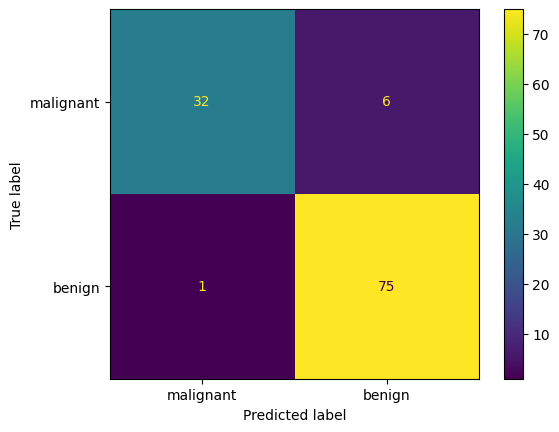

In [ ]:
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm,
                                    display_labels=breast_cancer.target_names)

cm_display.plot()
plt.show()

In [ ]:
kfold = KFold(n_splits=10, random_state=11, shuffle=True)

In [ ]:
scores = cross_val_score(estimator=nb, X=breast_cancer.data,
                         y=breast_cancer.target, cv=kfold)
print(scores)

[0.96491228 0.9122807  0.94736842 0.89473684 0.96491228 0.94736842
 0.96491228 0.89473684 0.96491228 0.92857143]


In [ ]:
estimators = {
    'GaussianNB': nb, 'KNeighborsClassifier': KNeighborsClassifier(),
    'LogisticRegression': LogisticRegression(solver='lbfgs', multi_class='ovr', max_iter=10000),
    'SVC': SVC(gamma='scale')
}


In [ ]:
for name, estimator in estimators.items():
  scores = cross_val_score(estimator=estimator, X=breast_cancer.data,
                           y=breast_cancer.target, cv=kfold)
  print(name)
  print("Average score:", scores.mean())
  print()

GaussianNB
Average score: 0.9384711779448622

KNeighborsClassifier
Average score: 0.9279135338345865



/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was depre

LogisticRegression
Average score: 0.950814536340852

SVC
Average score: 0.9191729323308271

